This notebook is part of the `kikuchipy` documentation https://kikuchipy.org.
Links to the documentation won't work from the notebook.

# Spherical indexing

In this tutorial, we will index EBSD patterns by spherical harmonic cross-correlation, kikuchipy's port of the `IndexEBSD` program of [EMSphInx](https://github.com/EMsoft-org/EMSphInx) ([Lenthe et al., 2019](https://doi.org/10.1016/j.ultramic.2019.112841)).
The master pattern and each experimental pattern are represented as functions on the sphere, and the orientation is found as the global maximum of their cross-correlation over all rotations: the correlation is expanded in generalized spherical harmonics and its maximum located with fast Fourier transforms over the three Euler angles.
The maximum is then refined to sub-grid precision with Newton's method on analytic derivatives, so refined orientations come out of moderately noisy patterns directly, without a pre-computed dictionary and, as [Lenthe et al. (2019)](https://doi.org/10.1016/j.ultramic.2019.112841) report, at a small fraction of the cost of dictionary indexing.

We'll use a tiny dataset of recrystallized, polycrystalline nickel available with kikuchipy, and validate the results against Hough indexing with [PyEBSDIndex](https://pyebsdindex.readthedocs.io) and against the refined orientations shipped with the dataset.

<div class="alert alert-info">

Note

Spherical indexing in kikuchipy is a port of the [EMSphInx](https://github.com/EMsoft-org/EMSphInx) C++ programs, which run on the CPU themselves.
The agreement with EMSphInx's own `IndexEBSD` program is measured and pinned by a regression suite shipped with kikuchipy; see [Interoperability with EMSphInx](#Interoperability-with-EMSphInx) below.

</div>

Let's import the necessary libraries

In [1]:
# Exchange inline for notebook or qt5 (from pyqt) for interactive plotting
%matplotlib inline

import tempfile
from pathlib import Path

import dask
import matplotlib.pyplot as plt
import numpy as np

import kikuchipy as kp
from orix import plot
from orix.crystal_map import PhaseList
from orix.quaternion import Orientation, symmetry

plt.rcParams.update({"figure.facecolor": "w", "font.size": 15})

Load the dataset of (75, 55) nickel EBSD patterns of (60, 60) pixels with a step size of 1.5 μm, and remove the static and dynamic background (see the [pattern processing tutorial](pattern_processing.ipynb) for details).
Maps of the quality of these patterns before indexing are shown in the [Hough indexing tutorial](hough_indexing.ipynb#Pre-indexing-maps), which uses the same dataset

In [2]:
s = kp.data.nickel_ebsd_large(allow_download=True)
s.remove_static_background()
s.remove_dynamic_background()
s

  0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]

<EBSD, title: patterns Scan 1, dimensions: (75, 55|60, 60)>

## Master pattern on the sphere

Spherical indexing correlates each experimental pattern with a dynamically simulated master pattern of the candidate phase, which must first be transformed into its spherical harmonic coefficients.
We use the nickel master pattern shipped with kikuchipy, simulated with EMsoft at a beam energy of 20.1 keV, read in the square Lambert projection with both hemispheres

In [3]:
mp = kp.data.nickel_ebsd_master_pattern_small(
    projection="lambert", hemisphere="both"
)
mp

<EBSDMasterPattern, title: ni_mc_mp_20kv_uint8_gzip_opts9, dimensions: (2|401, 401)>

[EBSDMasterPattern.get_spherical_harmonics()](../reference/generated/kikuchipy.signals.EBSDMasterPattern.get_spherical_harmonics.rst) computes the spherical harmonic coefficients up to a chosen bandwidth, the equivalent of EMSphInx's `mp2sht` program.
The bandwidth is the highest harmonic degree kept: a higher bandwidth resolves finer detail on the sphere, but costs more memory and time during indexing.
A square Lambert master pattern of side length $d$ carries information up to a harmonic degree of about $(d - 1) / 2$, here $(401 - 1) / 2 = 200$, and asking for more warns.
We use 188, a fast bandwidth comfortably under this limit -- ample for these patterns (see [Choosing the bandwidth](#Choosing-the-bandwidth) below) -- which indexing resizes down to its own bandwidth internally

In [4]:
harmonics = mp.get_spherical_harmonics(bandwidth=188)
harmonics

MasterPatternHarmonics: bw = 188, ni (m-3m), 20.1 keV, 70.0 deg

<div class="alert alert-info">

Note

For your own data, use the highest resolution master pattern available.
[kikuchipy.data.ebsd_master_pattern()](../reference/generated/kikuchipy.data.ebsd_master_pattern.rst) downloads full resolution (1001, 1001) master patterns of nickel and other phases to a local cache -- 0.2 to 3 GB each depending on the phase, about 300 MB for nickel -- which carry bandwidths up to 500

```python
mp = kp.data.ebsd_master_pattern(
    "ni", projection="lambert", energy=20, allow_download=True
)
```

</div>

Master patterns of many other phases are available as EMSphInx `.sht` files from the SHT database, linked from our [related projects](../user/related_projects.rst) page, and are read directly with `kp.load()`.

The harmonic representation is compact.
Its rotationally invariant power spectrum gives the power carried by each harmonic degree $l$.
The master pattern is centrosymmetric, so all odd degrees vanish -- they come out around $10^{-30}$ -- and we plot the even ones.
The constant term at $l = 0$ is the mean of the master pattern; the rest peaks near $l = 45$ and then decays, with under 1% of the total power above $l = 150$

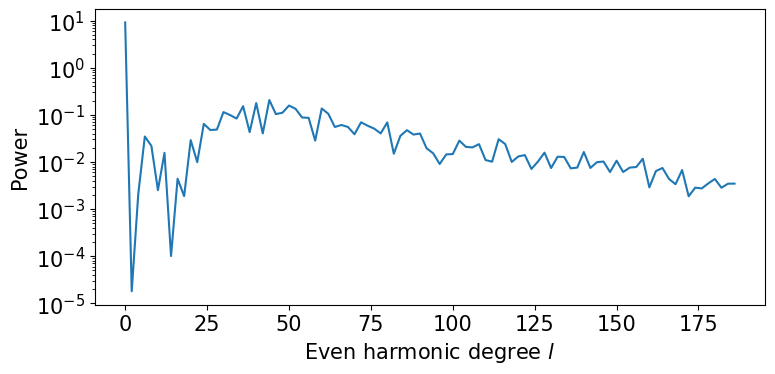

In [5]:
power = harmonics.power_spectrum()
degrees = np.arange(0, power.size, 2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(degrees, power[degrees])
ax.set(xlabel="Even harmonic degree $l$", ylabel="Power")
fig.tight_layout()

A band-limited master pattern can be synthesized back from the coefficients with [MasterPatternHarmonics.to_master_pattern()](../reference/generated/kikuchipy.indexing.MasterPatternHarmonics.to_master_pattern.rst).
We ask for the same (401, 401) grid as the original, so that the two panels are directly comparable.
Fine detail is smoothed by the band limit, but the bands and zone axes that indexing correlates on come back intact

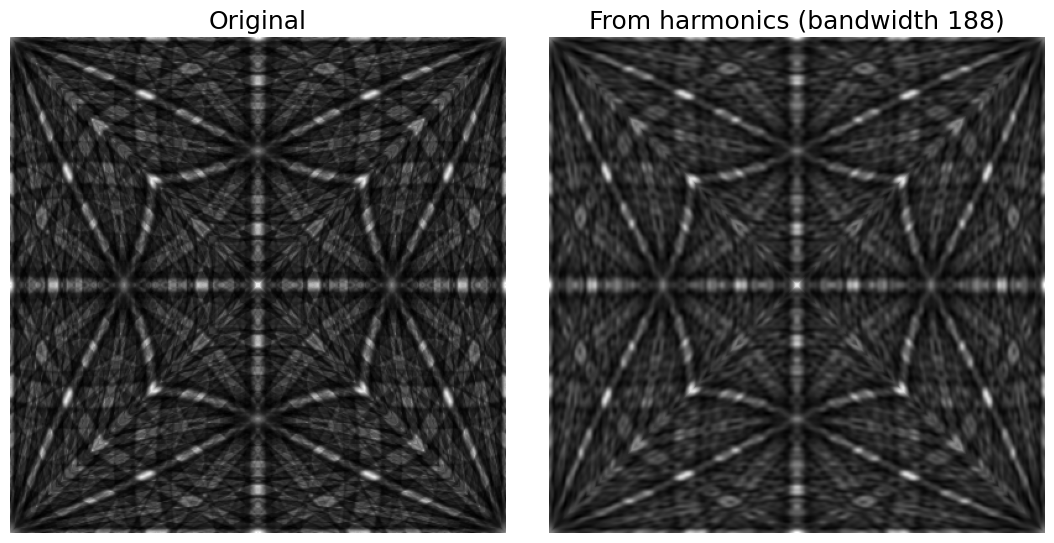

In [6]:
mp_synth = harmonics.to_master_pattern(dim=401)

fig, axes = plt.subplots(ncols=2, figsize=(11, 5.5))
axes[0].imshow(mp.data[0], cmap="gray")
axes[0].set(title="Original")
axes[1].imshow(mp_synth.data[0], cmap="gray")
axes[1].set(title="From harmonics (bandwidth 188)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

## Calibrate detector-sample geometry

Like every indexing method, spherical indexing needs the position of the sample with respect to the detector: the projection center (PC) and the detector and sample tilts (see the [reference frames tutorial](reference_frames.ipynb) for the conventions).
This dataset is shipped with a calibrated detector.
We use the average PC of all patterns, since spherical indexing, like EMSphInx, uses a single PC per map; see the [Hough indexing tutorial](hough_indexing.ipynb#Calibrate-detector-sample-geometry) for how to estimate a PC from scratch

In [7]:
det = s.detector.deepcopy()
det.pc = det.pc_average
det

EBSDDetector
  shape (Ny, Nx):     (60, 60)
  pc (PCx, PCy, PCz): (0.423, 0.214, 0.502)
  sample_tilt:        70.0°
  tilt:               0.0°
  azimuthal:          0.0°
  twist:              0.0°
  binning:            8
  px_size:            1.0 um

The master pattern was simulated for a sample tilt of 70°, which the harmonics carry with them, and our detector states the same sample tilt.
The two must agree.
Indexing with mismatched tilts returns systematically wrong orientations at deceptively *higher* scores, so kikuchipy compares the sample tilt of the harmonics with the one of the detector and refuses to index when they differ.

## Back-projection onto the sphere

During indexing, every pattern is back-projected onto the sphere through the detector geometry.
This step is public as [SphericalBackProjector](../reference/generated/kikuchipy.indexing.SphericalBackProjector.rst), so we can look at it.
A pattern covers only the solid angle subtended by the detector, the "window", and the rest of the sphere is unknown; the correlation accounts for this by normalizing with the window function

Image quality: 0.349


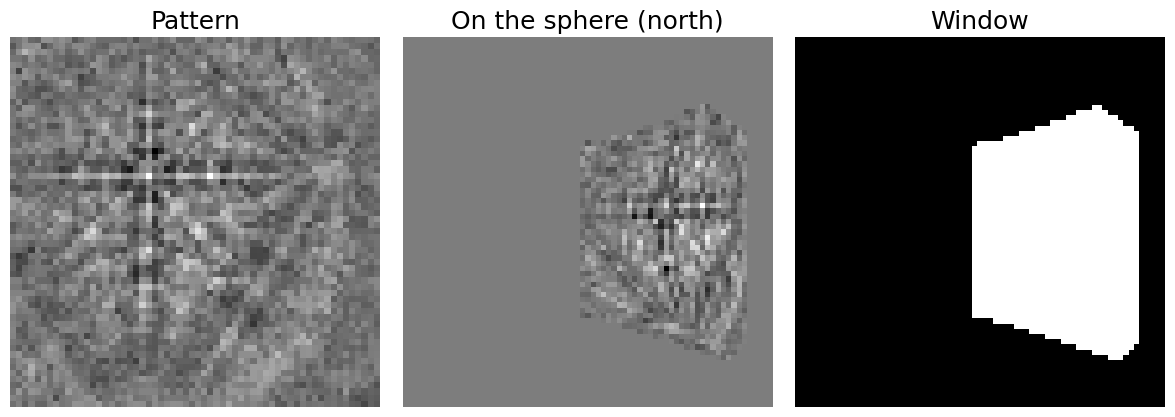

In [8]:
projector = kp.indexing.SphericalBackProjector(det, bandwidth=68)
pattern = s.inav[0, 0].data
north, south, iq = projector.unproject(pattern, return_image_quality=True)

fig, axes = plt.subplots(ncols=3, figsize=(12, 4.5))
axes[0].imshow(pattern, cmap="gray")
axes[0].set(title="Pattern")
axes[1].imshow(north, cmap="gray")
axes[1].set(title="On the sphere (north)")
axes[2].imshow(projector.window_mask()[0], cmap="gray")
axes[2].set(title="Window")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

print(f"Image quality: {iq:.3f}")

The pattern lands on the square Legendre grid of the northern hemisphere: the sample surface faces north, and the part of the sphere below the sample plane is never seen, which is why the southern grid comes back empty.
The image quality, computed from the pattern's cosine transform, is also returned as the `"iq"` map property during indexing.
Indexing measures it on the adaptive histogram equalized pattern it back-projects rather than on the raw one, so the values in that map come out lower than the one printed here.

## Perform indexing

Spherical indexing runs in parallel over chunks of patterns with Dask's threaded scheduler.
Every worker thread needs a private correlation buffer whose size grows with the third power of the bandwidth (54 MB per worker at bandwidth 68 with refinement, as the informational message below prints), so the memory a run needs is set by the number of workers.
We limit this one to eight of them, which bounds the memory and keeps the printed output of this tutorial independent of the machine it runs on; leave it out to use all cores

In [9]:
_ = dask.config.set(num_workers=8)

We index with [EBSD.spherical_indexing()](../reference/generated/kikuchipy.signals.EBSD.spherical_indexing.rst), passing the harmonics and the calibrated detector.
Every other parameter is left at its default, so this call reproduces EMSphInx's own namelist defaults: a bandwidth of 68, and Newton refinement of the correlation maximum (`refine=True`), which returns orientations already refined to well below the spacing of the correlation grid

In [10]:
xmap = s.spherical_indexing(harmonics, det, bandwidth=68)

Spherical indexing information:
  Phase(s): ni (m-3m; 4-fold, mirror)
  Bandwidth: 68 (Euler side length 135, half cell 1.33 deg)
  Correlation: normalized
  Refinement: Newton (on)
  Preprocessing: n_regions = 10, gaussian_background = False
  Projection center (Bruker): (0.4233, 0.2136, 0.5021)
  Indexing 4125 pattern(s) in 275 chunk(s) of up to 15 pattern(s)
  Estimated memory per worker: 54 MB


[                                        ] | 0% Completed | 571.70 us

[                                        ] | 0% Completed | 106.96 ms

[                                        ] | 0% Completed | 208.60 ms

[                                        ] | 0% Completed | 309.98 ms

...

[######################################  ] | 97% Completed | 20.40 s

[######################################  ] | 97% Completed | 20.50 s

[####################################### ] | 99% Completed | 20.60 s

[########################################] | 100% Completed | 20.70 s

  Indexing speed: 198.88835 patterns/s

In [11]:
xmap

Phase   Orientations  Name  Space group  Point group  Proper point group     Color
    0  4125 (100.0%)    ni        Fm-3m         m-3m                 432  tab:blue
Properties: scores, iq
Scan unit: um

All 4125 patterns were indexed in about 20 s on eight Dask workers of a 20-core desktop CPU, refinement included; the printed `Indexing speed` is the number to compare on your own machine.
The returned [CrystalMap](https://orix.readthedocs.io/en/stable/reference/generated/orix.crystal_map.CrystalMap.html) carries two properties: `"scores"`, the correlation at the best orientation, and `"iq"`, the image quality of the back-projected pattern.
The score is the spherical correlation at the (refined) maximum, divided by the rotation dependent window denominator because `normalize=True` -- it is *not* a bounded normalized cross-correlation.
It is comparable only within one detector geometry and bandwidth, and can neither be passed to [orientation_similarity_map()](../reference/generated/kikuchipy.indexing.orientation_similarity_map.rst) nor be compared with the normalized cross-correlation scores of dictionary indexing.
Let's look at the two maps

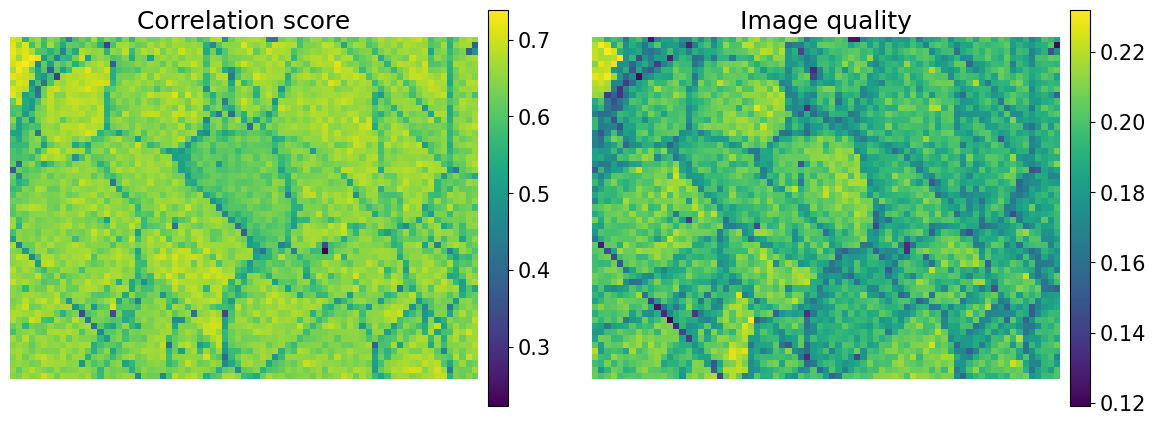

In [12]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4.5))
for ax, prop, title in zip(
    axes, ["scores", "iq"], ["Correlation score", "Image quality"]
):
    im = ax.imshow(xmap.get_map_data(prop))
    ax.axis("off")
    ax.set(title=title)
    fig.colorbar(im, ax=ax, pad=0.02)
fig.tight_layout()

The scores are high and uniform within grains and dip at grain boundaries, where patterns from two grains mix; the image quality map shows the same microstructure.
As with the other indexing methods, the results can be exported with [orix](https://orix.readthedocs.io/en/stable/reference/generated/orix.io.save.html) to an HDF5 file or to a text file (.ang) importable by other software

In [13]:
# from orix import io
# io.save("xmap_ni.h5", xmap)
# io.save("xmap_ni.ang", xmap, image_quality_prop="iq")

### Choosing the bandwidth

The indexing bandwidth trades accuracy for speed and memory.
Because the correlation is computed with FFTs, only bandwidths whose transform sizes factorize well are fast; [kikuchipy.indexing.fast_bandwidths()](../reference/generated/kikuchipy.indexing.fast_bandwidths.rst) lists them

In [14]:
kp.indexing.fast_bandwidths(bandwidth_min=50, bandwidth_max=130)

array([ 50,  53,  59,  61,  63,  68,  72,  74,  83,  85,  88,  95,  98,
       113, 116, 122, 123])

Let's index a subset of the map at three of these bandwidths without refinement, so that the resolution of the coarse Euler grid shows, and compare each solution to the refined map above.
Scores of different bandwidths are not comparable, so we report the misorientation to that map instead.
The subset is taken as `s.inav[:40, :30]`, which is x-then-y, while the matching part of the crystal map is `xmap[:30, :40]`, which is row-then-column.
Slicing the crystal map is the way to extract the corresponding orientations: reshaping and flattening the rotations by hand scrambles the map order

In [15]:
from time import time

s_sub = s.inav[:40, :30]
ori_sub = Orientation(xmap[:30, :40].rotations, symmetry.Oh)

for bw in [53, 68, 88]:
    t0 = time()
    xmap_bw = s_sub.spherical_indexing(
        harmonics, det, bandwidth=bw, refine=False, verbose=0
    )
    speed = s_sub.axes_manager.navigation_size / (time() - t0)
    ang = Orientation(xmap_bw.rotations, symmetry.Oh).angle_with(
        ori_sub, degrees=True
    )
    print(
        f"Bandwidth {bw}: median {np.median(ang):.2f} deg, "
        f"p99 {np.percentile(ang, 99):.2f} deg to the refined map, "
        f"{speed:.1f} patterns/s"
    )

Bandwidth 53: median 0.37 deg, p99 1.40 deg to the refined map, 405.6 patterns/s


Bandwidth 68: median 0.37 deg, p99 0.71 deg to the refined map, 220.3 patterns/s


Bandwidth 88: median 0.25 deg, p99 0.69 deg to the refined map, 104.2 patterns/s


The coarse error is bounded by half a cell of the Euler grid -- 1.7, 1.3 and 1.0° at bandwidths 53, 68 and 88 -- and its tail tightens with the bandwidth, at a cost which grows roughly with its cube.
Newton refinement removes most of the grid error, which is why the default bandwidth of 68 *with* refinement is the compromise -- and EMSphInx's own namelist default.
The residual against the shipped orientations is set by the PC calibration together with the band limit -- a larger bandwidth still shrinks it (the [EBSD.spherical_indexing()](../reference/generated/kikuchipy.signals.EBSD.spherical_indexing.rst) docstring's measurement: median 0.51° at bandwidth 68 against 0.45° at 88).

## Validate indexing results

We compare our solution to two others on the same dataset: Hough indexing with PyEBSDIndex, run here (see the [Hough indexing tutorial](hough_indexing.ipynb)), and the Hough-indexed, dynamically refined orientations shipped with the dataset, which were refined with a PC per pattern.
Neither is an independent method -- the shipped map is the same Hough engine plus a refinement -- so what follows measures agreement, not accuracy.

For Hough indexing we need a phase list.
Building it from the master pattern's phase keeps the lattice parameters identical (kikuchipy's EMsoft readers use nm); [EBSD.refine_orientation_spherical()](../reference/generated/kikuchipy.signals.EBSD.refine_orientation_spherical.rst) raises a `ValueError` if they differ, so a phase built as in the [Hough indexing tutorial](hough_indexing.ipynb) (in Å) would be refused.
The indexer settings are that tutorial's

In [16]:
phase_list = PhaseList(mp.phase.deepcopy())
phase_list

Id  Name  Space group  Point group  Proper point group     Color
 0    ni        Fm-3m         m-3m                 432  tab:blue

In [17]:
indexer = det.get_indexer(
    phase_list,
    [[1, 1, 1], [2, 0, 0], [2, 2, 0], [3, 1, 1]],
    nBands=10,
    tSigma=2,
    rSigma=2,
)
xmap_hough = s.hough_indexing(
    phase_list=phase_list, indexer=indexer, verbose=0
)
xmap_hough

Hough indexing with PyEBSDIndex information:
  PyOpenCL: False
  Projection center (Bruker): (0.4233, 0.2136, 0.5021)
  Indexing 4125 pattern(s) in 8 chunk(s)


  Indexing speed: 922.04819 patterns/s


Phase   Orientations         Name  Space group  Point group  Proper point group     Color
   -1       1 (0.0%)  not_indexed         None         None                None     white
    0  4124 (100.0%)           ni        Fm-3m         m-3m                 432  tab:blue
Properties: fit, cm, pq, nmatch
Scan unit: um

One of the 4125 patterns could not be indexed by PyEBSDIndex and is left as `not_indexed`, as the crystal map above shows; it is left white in the maps below and masked out of the comparisons.

Create a color key to get IPF colors with

In [18]:
ckey = plot.IPFColorKeyTSL(symmetry.Oh)
ckey

IPFColorKeyTSL, symmetry: m-3m, direction: [0 0 1]

Each point is colored by which crystal direction $\left<uvw\right>$ points along the sample Z direction, out of the map plane.
Let's plot the IPF-Z maps of the three solutions side by side, with the color key next to them

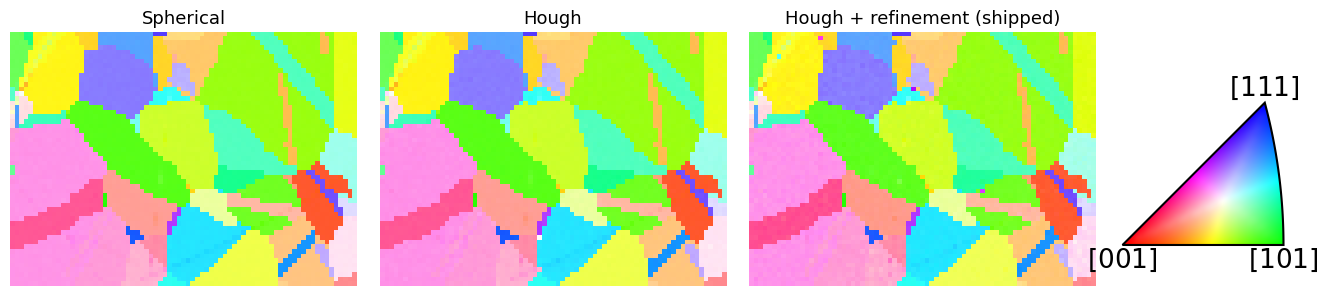

In [19]:
fig, axes = plt.subplots(ncols=3, figsize=(13, 3.6))
for ax, xm, title in zip(
    axes,
    [xmap, xmap_hough, s.xmap],
    ["Spherical", "Hough", "Hough + refinement (shipped)"],
):
    rgb = ckey.orientation2color(Orientation(xm.rotations, symmetry.Oh))
    # Leave the point Hough indexing could not index white
    rgb[xm.phase_id.flatten() == -1] = 1
    ax.imshow(rgb.reshape(xm.shape + (3,)))
    ax.axis("off")
    ax.set_title(title, fontsize=13)
fig.tight_layout(rect=[0, 0, 0.87, 1])

# Place color key to the right of the maps, coordinates are
# [left, bottom, width, height]
ax_ckey = fig.add_axes(
    [0.87, 0.06, 0.13, 0.8], projection="ipf", symmetry=symmetry.Oh
)
ax_ckey.plot_ipf_color_key(show_title=False)
ax_ckey.patch.set_facecolor("None")

The three maps are indistinguishable by eye.
Let's quantify the disagreement as the misorientation angle at every map point

To Hough (masked):    median 0.23 deg, p99 0.75 deg
To shipped (refined): median 0.43 deg, p99 1.53 deg


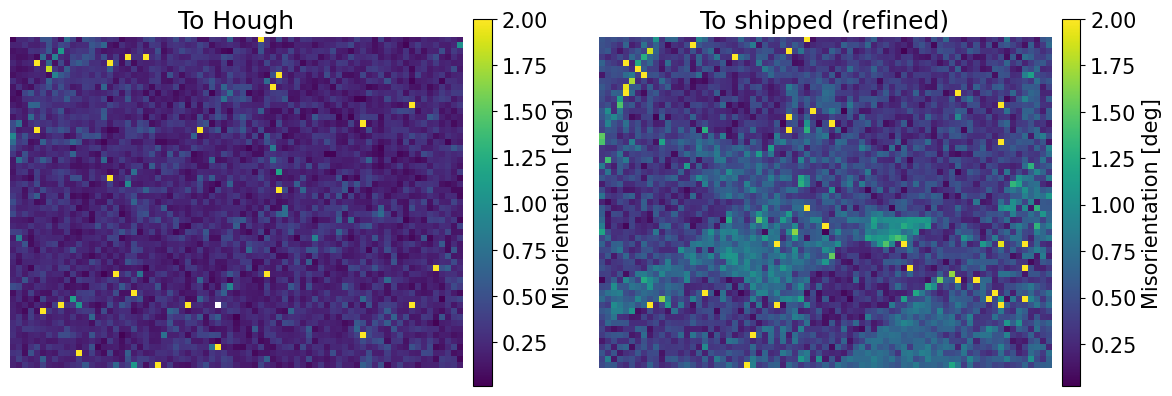

In [20]:
mask = xmap_hough.phase_id.flatten() != -1

ori_sph = Orientation(xmap.rotations, symmetry.Oh)
ori_hough = Orientation(xmap_hough.rotations, symmetry.Oh)
ori_shipped = Orientation(s.xmap.rotations, symmetry.Oh)

ang_hough = ori_sph.angle_with(ori_hough, degrees=True)
ang_shipped = ori_sph.angle_with(ori_shipped, degrees=True)

print(
    f"To Hough (masked):    median {np.median(ang_hough[mask]):.2f} deg,"
    f" p99 {np.percentile(ang_hough[mask], 99):.2f} deg\n"
    f"To shipped (refined): median {np.median(ang_shipped):.2f} deg,"
    f" p99 {np.percentile(ang_shipped, 99):.2f} deg"
)

fig, axes = plt.subplots(ncols=2, figsize=(12, 4.2))
for ax, ang, title in zip(
    axes,
    [np.where(mask, ang_hough, np.nan), ang_shipped],
    ["To Hough", "To shipped (refined)"],
):
    im = ax.imshow(ang.reshape(xmap.shape), vmax=2)
    ax.axis("off")
    ax.set(title=title)
    fig.colorbar(im, ax=ax, pad=0.02, label="Misorientation [deg]")
fig.tight_layout()

Both comparisons agree to a fraction of a degree over the whole map.
The color scale saturates at 2°, above which a few tens of points lie: grain boundaries and twins, where the engines resolve the pattern mixing differently or pick a different solution altogether.
Most of the 0.43° to the shipped map is the difference in projection center -- it was refined with a PC per pattern, while we index with one average PC -- and in refinement, not in the indexing itself.

## Refining orientations from another source

Newton refinement on the sphere is also available on its own, as [EBSD.refine_orientation_spherical()](../reference/generated/kikuchipy.signals.EBSD.refine_orientation_spherical.rst).
Any crystal map with orientations for our patterns can be refined this way, whatever produced it.
Let's refine the Hough result

In [21]:
xmap_hough_ref = s.refine_orientation_spherical(
    xmap_hough, harmonics, det, bandwidth=68
)

Spherical indexing information:
  Phase(s): ni (m-3m; 4-fold, mirror)
  Bandwidth: 68 (Euler side length 135, half cell 1.33 deg)
  Correlation: normalized
  Refinement: Newton (on)
  Preprocessing: n_regions = 10, gaussian_background = False
  Projection center (Bruker): (0.4233, 0.2136, 0.5021)
  Refining 4124 orientation(s) in 275 chunk(s) of up to 15 pattern(s)
  Estimated memory per worker: 54 MB


[                                        ] | 0% Completed | 561.00 us

[                                        ] | 0% Completed | 102.84 ms

[#                                       ] | 3% Completed | 206.10 ms

[##                                      ] | 7% Completed | 307.86 ms

...

[#####################################   ] | 93% Completed | 3.81 s

[######################################  ] | 96% Completed | 3.91 s

[####################################### ] | 98% Completed | 4.01 s

[########################################] | 100% Completed | 4.11 s

  Refinement speed: 991.56464 patterns/s


Refinement never re-indexes, it only improves the orientation it is given, so the one point Hough indexing left unindexed keeps its input row.
If refinement works, the refined Hough orientations should land on the same correlation maxima that spherical indexing found.
They do

Median after refinement: 0.042 deg


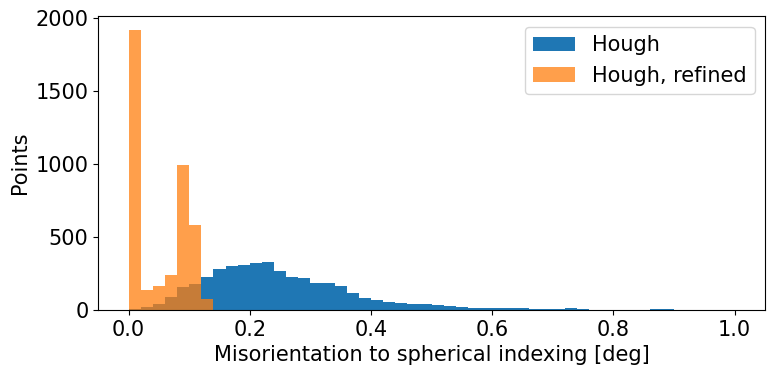

In [22]:
ori_ref = Orientation(xmap_hough_ref.rotations, symmetry.Oh)
angles_ref = ori_ref.angle_with(ori_sph, degrees=True)[mask]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ang_hough[mask], bins=50, range=(0, 1), label="Hough")
ax.hist(
    angles_ref, bins=50, range=(0, 1), alpha=0.75, label="Hough, refined"
)
ax.set(xlabel="Misorientation to spherical indexing [deg]", ylabel="Points")
ax.legend()
fig.tight_layout()

print(f"Median after refinement: {np.median(angles_ref):.3f} deg")

The misorientation to the spherical indexing solution drops from about a quarter of a degree to a few hundredths, and the refined histogram has two modes: just under half of the points land on the spherical solution to within 0.02°, and almost all of the rest within 0.15° of it.
Both engines converge to the same maxima of the same correlation function.

## Interoperability with EMSphInx

kikuchipy reads and writes EMSphInx's file formats, so master patterns, patterns and indexing parameters can be exchanged both ways.

Spherical harmonics are written to EMSphInx's `.sht` format with [MasterPatternHarmonics.save()](../reference/generated/kikuchipy.indexing.MasterPatternHarmonics.save.rst); files from the [SHT database](../user/related_projects.rst) are read with [kikuchipy.load()](../reference/generated/kikuchipy.load.rst), which returns a master pattern synthesized from the stored harmonics on the default grid for their bandwidth, `2 * bandwidth + 1` points across -- 377 here, not the 401 we started from

In [23]:
temp_dir = Path(tempfile.mkdtemp())

harmonics.save(temp_dir / "ni_20kv.sht")
mp_sht = kp.load(temp_dir / "ni_20kv.sht")
mp_sht

<EBSDMasterPattern, title: ni_20kv, dimensions: (2|377, 377)>

To index our patterns with the EMSphInx `IndexEBSD` program itself, we write them to the repacked HDF5 layout it reads ([write_emsphinx_patterns()](../reference/generated/kikuchipy.indexing.write_emsphinx_patterns.rst), the `PatternRepack` equivalent) and generate its namelist input file from our detector and indexing parameters with [EMSphInxNamelist](../reference/generated/kikuchipy.indexing.EMSphInxNamelist.rst)

In [24]:
kp.indexing.write_emsphinx_patterns(temp_dir / "patterns.h5", s)

nml = kp.indexing.EMSphInxNamelist.from_kwargs(
    pattern_file="patterns.h5",
    master_files=["ni_20kv.sht"],
    detector=det,
    scan_shape=(55, 75),
    scan_steps=(1.5, 1.5),
    data_file="out.h5",
    bandwidth=68,
    n_thread=8,
)
nml.write(temp_dir / "IndexEBSD.nml")

print("\n".join(nml.to_string().splitlines()[:5]))

 &EMSphInx
!#################################################################
! Input Files
!#################################################################



Running `IndexEBSD IndexEBSD.nml` in that directory runs the same indexing on the same patterns and master with the original C++ program.
The correspondence between the namelist parameters and the kikuchipy arguments is:

| EMSphInx namelist | kikuchipy | note |
|---|---|---|
| `patfile`, `patdset` | `write_emsphinx_patterns()` | pattern file and HDF5 dataset |
| `masterfile` | `MasterPatternHarmonics.save()` | `.sht` master pattern(s) |
| `patdims` | detector shape | |
| `scandims` | navigation shape and scan steps | x-then-y order |
| `pctr`, `thetac` | `EBSDDetector` | PC converted from `pc_average`, camera tilt |
| `vendor` | `from_kwargs()` argument | `"Bruker"` by default, for which `pctr` is the kikuchipy PC verbatim |
| `delta` | `from_kwargs()` argument | pixel size in μm; deliberately *not* `detector.px_size`, defaulting to a detector exactly 30 mm wide |
| `bw` | `bandwidth` | default 68 |
| `normed` | `normalize` | default `True` |
| `refine` | `refine` | default `True` |
| `nregions` | `n_regions` | adaptive histogram equalization |
| `gausbckg` | `gaussian_background` | Gaussian background fit |
| `circmask` | `circular_mask` | default off (`-1`) |
| `nthread`, `batchsize` | Dask `num_workers`, `chunksize` | threading |
| `roimask` | -- | region of interest, written empty: the whole scan |
| `datafile` | `data_file` | output orientation map of `IndexEBSD` |

The agreement between the two implementations is measured and pinned by a regression suite shipped with kikuchipy, which compares both engines on these nickel datasets at bandwidth 68, against the master pattern shipped as `ni_small_20kv_bw384.sht`: orientations agree to a median misorientation of about 0.34°, correlation scores to about 2%, and image qualities to floating-point precision.
These numbers are for that configuration; your own bandwidth and master pattern will differ.
Most of the remaining orientation difference is a documented half-pixel detector-sampling convention difference in EMSphInx; accounting for it, the two agree to better than 0.1°.

In [25]:
# Remove files written to disk in this tutorial
import os

for file in os.listdir(temp_dir):
    os.remove(temp_dir / file)
os.rmdir(temp_dir)

temp_dir.exists()

False

## What's next?

Spherical indexing complements the other indexing methods in kikuchipy:

- [Hough indexing](hough_indexing.ipynb) is faster still and needs no master pattern, but returns unrefined orientations of lower precision.
- [Dictionary indexing](pattern_matching.ipynb) handles the noisiest patterns, and its per-pattern similarity scores support multi-phase discrimination in difficult cases; [Lenthe et al. (2019)](https://doi.org/10.1016/j.ultramic.2019.112841) report it to be substantially more expensive than spherical indexing at comparable angular resolution.
- [Hybrid indexing](hybrid_indexing.ipynb) refines orientations from Hough indexing *and* the projection center of every pattern with gradient-free optimization.

For multi-phase spherical indexing, pass a list of harmonics, one per candidate phase, to `EBSD.spherical_indexing()`.